In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style grafik
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load dataset
df = pd.read_csv('../../raw dataset/diabetes_binary_health_indicators_BRFSS2015.csv')

# Cek ukuran data
print(f'Jumlah baris: {df.shape[0]:,}')
print(f'Jumlah kolom: {df.shape[1]}')

# Lihat 5 baris pertama
df.head()

Jumlah baris: 253,680
Jumlah kolom: 22


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [2]:
# Detail tiap kolom
print(df.info())
print()
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [3]:
# Cek missing values
missing = df.isnull().sum()
print('Missing values per kolom:')
print(missing[missing > 0] if missing.any() else 'Tidak ada missing values')

Missing values per kolom:
Tidak ada missing values


Distribusi target variable:
0 (Non-diabetes)L 218,334 (86.1%)
1 (Diabetes/Pre): 35,346 (13.9%)

Ratio: 1 diabetes per 6.2 non-diabetes


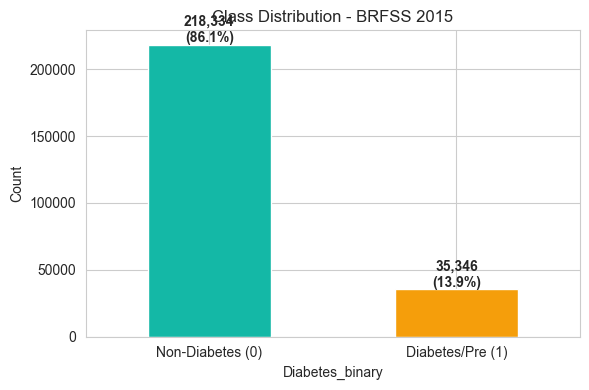

In [4]:
# Cek class imbalance
target_counts = df['Diabetes_binary'].value_counts()
target_pct = df['Diabetes_binary'].value_counts(normalize=True) * 100

print('Distribusi target variable:')
print(f'0 (Non-diabetes)L {target_counts[0]:,} ({target_pct[0]:.1f}%)')
print(f'1 (Diabetes/Pre): {target_counts[1]:,} ({target_pct[1]:.1f}%)')
print(f'\nRatio: 1 diabetes per {target_counts[0]/target_counts[1]:.1f} non-diabetes')

# Visualisasi
fig, ax = plt.subplots(figsize=(6,4))
colors = ['#14B8A6', '#F59E0B']
target_counts.plot(kind='bar', color=colors, ax=ax)
ax.set_xticklabels(['Non-Diabetes (0)', 'Diabetes/Pre (1)'], rotation=0)
ax.set_title('Class Distribution - BRFSS 2015')
ax.set_ylabel('Count')
for i, v in enumerate(target_counts):
    ax.text(i, v + 2000, f'{v:,}\n({target_pct.iloc[i]:.1f}%)', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

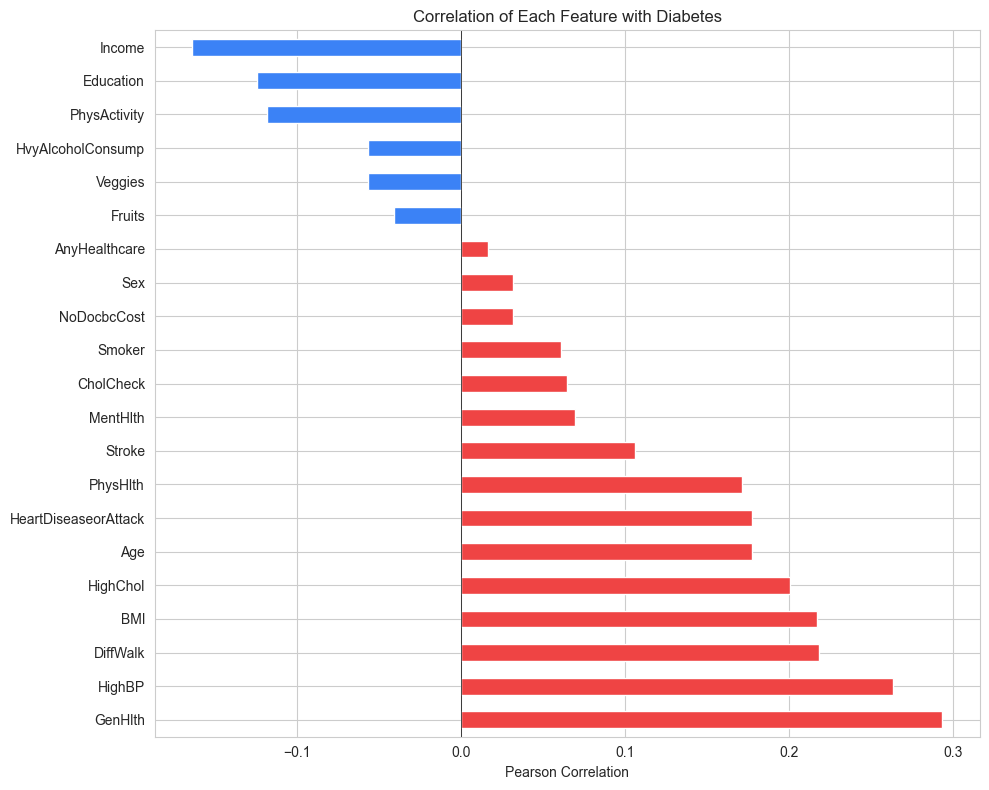


Top 5 fitur paling berkorelasi:
GenHlth     0.293569
HighBP      0.263129
DiffWalk    0.218344
BMI         0.216843
HighChol    0.200276
Name: Diabetes_binary, dtype: float64


In [7]:
# Hitung korelasi setiap fitur dengan target
correlations = df.corr()['Diabetes_binary'].drop('Diabetes_binary').sort_values(ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#EF4444' if x > 0 else '#3B82F6' for x in correlations]
correlations.plot(kind='barh', color=colors, ax=ax)
ax.set_title('Correlation of Each Feature with Diabetes')
ax.set_xlabel('Pearson Correlation')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nTop 5 fitur paling berkorelasi:")
print(correlations.head())

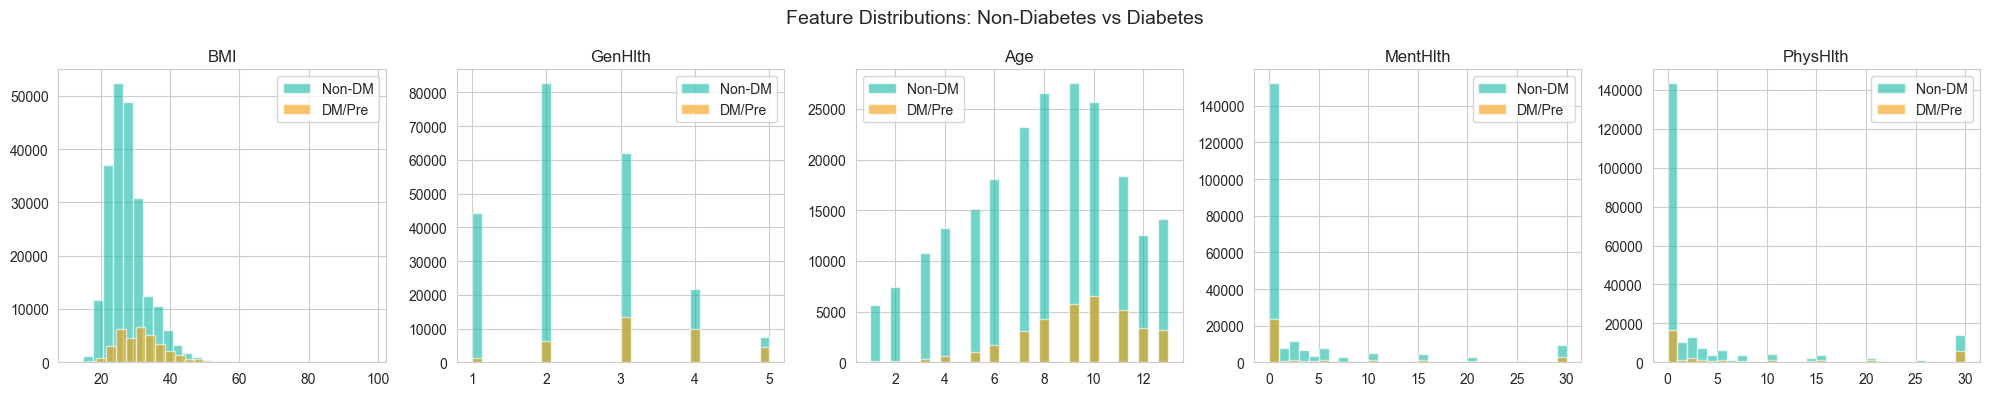

In [8]:
# Visualisasi fitur penting
important_features = ['BMI', 'GenHlth', 'Age', 'MentHlth', 'PhysHlth']

fig, axes = plt.subplots(1, len(important_features), figsize=(20, 4))
for i, feat in enumerate(important_features):
    for label, color in [(0, '#14B8A6'), (1, '#F59E0B')]:
        subset = df[df['Diabetes_binary'] == label][feat]
        axes[i].hist(subset, bins=30, alpha=0.6, color=color, 
                     label='Non-DM' if label == 0 else 'DM/Pre')
    axes[i].set_title(feat)
    axes[i].legend()
plt.suptitle('Feature Distributions: Non-Diabetes vs Diabetes', fontsize=14)
plt.tight_layout()
plt.show()